In [1]:
import os
import pandas as pd
import scanpy as sc
import hotspot
import matplotlib.pyplot as plt
from scipy.io import mmread
import seaborn as sns
import gseapy as gp
from adjustText import adjust_text
import numpy as np
from pathlib import Path

In [2]:
## Input The Main Directory ##
main_directory = Path('/path/to/Jiang_etal_2026_HTAN')

In [3]:
output_dir = main_directory / "output"

input_dir = main_directory / "input"

figures_dir = output_dir / "figures"

figures_extended_data_dir = figures_dir / "figures_extended_data"
figures_main_dir = figures_dir / "figures_main"

figures_main_1g = figures_main_dir / "figure_1g"
figures_main_1g.mkdir(parents=True, exist_ok=True)

figures_main_1h = figures_main_dir / "figure_1h"
figures_main_1h.mkdir(parents=True, exist_ok=True)

figures_main_1i = figures_main_dir / "figure_1i"
figures_main_1i.mkdir(parents=True, exist_ok=True)

figures_extended_data_1g = figures_extended_data_dir / "figure_1g"

# Tumor Cell Types

In [4]:
autocorrelations_tumor = pd.read_csv(figures_extended_data_1g/'hotspot.autocorrelations_tumor.tsv', sep='\t', index_col=0)

In [5]:
zfp36l2_correlations_tumor = autocorrelations_tumor[['ZFP36L2']]
zfp36l2_correlations_tumor = zfp36l2_correlations_tumor.sort_values(by='ZFP36L2', ascending=False)

In [6]:
zfp36l2_correlations_tumor.to_csv(figures_main_1h/"ZFP36L2_autocorrelations_tumor.csv")

In [7]:
gmt_file = input_dir / "pathways_for_gsea.gmt"

In [8]:
gmt_dict = {}
with open(gmt_file, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        pathway = parts[0]
        genes = parts[2:]  
        gmt_dict[pathway] = genes

In [9]:
AP1_genes = []

for pathway, genes in gmt_dict.items():
    if 'pid_ap1' in pathway.lower():
        AP1_genes.extend(genes)

AP1_genes = list(set(AP1_genes))

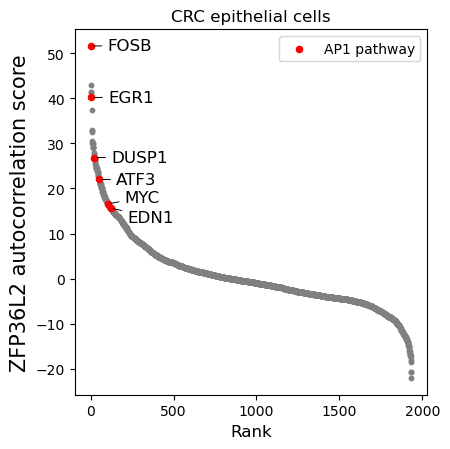

In [10]:
highlight_genes_tumor = ['FOSB', 'EGR1', 'DUSP1','ATF3','EDN1','MYC']
highlight_color_tumor = 'red'
label_color_tumor = 'black'

plt.figure(figsize=(4.6, 4.6))

zfp36l2_sorted_tumor = zfp36l2_correlations_tumor.sort_values(by='ZFP36L2', ascending=False)
x = range(len(zfp36l2_sorted_tumor))
y = zfp36l2_sorted_tumor['ZFP36L2'].values
plt.scatter(x, y, color='gray', s=10)

label_spacing = {
    'PABPC1': -2, #-2
    'EEF2': -3.5,
    'FOS': -3,
    'MYC': 1.4,
    'EDN1': -2,
    'JUNB': -2,
    'JUN': -3,
}

for i, gene in enumerate(zfp36l2_sorted_tumor.index):
    if gene in highlight_genes_tumor:
        score = zfp36l2_sorted_tumor.loc[gene, 'ZFP36L2']
        plt.scatter(i, score, color=highlight_color_tumor, s=20)

        label_x = i + 100
        label_y = score + label_spacing.get(gene, 0)

        plt.annotate(
            gene,
            xy=(i, score),
            xytext=(label_x, label_y),
            textcoords='data',
            fontsize=12,
            color=label_color_tumor,
            ha='left',
            va='center',
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7),
        )

plt.xlabel('Rank', fontsize = 12)
plt.ylabel('ZFP36L2 autocorrelation score', fontsize = 15)
plt.title('CRC epithelial cells')
plt.scatter([], [], color=highlight_color_tumor, label='AP1 pathway', s=20)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig(figures_main_1h/"ZFP36L2_autocorrelation_ranked_genes_tumor.pdf", bbox_inches='tight')

#plt.show()

## GSEA of Tumor Cells Autocorrelation

In [11]:
ranked_genes_tumor = zfp36l2_correlations_tumor.reset_index()
ranked_genes_tumor.columns = ['Gene', 'Correlation']
ranked_genes_tumor['Rank'] = ranked_genes_tumor['Correlation']

In [12]:
ranked_genes_tumor.columns = ['Gene', 'Correlation', 'Rank']

ranked_genes_tumor = ranked_genes_tumor[['Gene', 'Rank']]

ranked_genes_tumor.loc[:, 'Rank'] = pd.to_numeric(ranked_genes_tumor['Rank'], errors='coerce')

In [13]:
enr_tumor = gp.prerank(
    rnk=ranked_genes_tumor,
    gene_sets=str(gmt_file),
    #outdir='gsea_results',         
    permutation_num=1000,         
    min_size=15,                   
    max_size=500,                  
    seed=123                       
)

In [14]:
gsea_res_tumor = enr_tumor.res2d

In [15]:
gsea_res_sig_tumor = gsea_res_tumor[gsea_res_tumor['FDR q-val'] < 0.05] 

gsea_res_sig_tumor.to_csv(figures_extended_data_1g/"ZFP36L2_autocorrelation_GSEA_results_significant_tumor.csv", index=False)

In [16]:
plot_terms_tumor = {
    # Positive autocorrelation
    "HotSpotModule_27.STRESS_": "MODULE27-Stress",
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": "Hallmark-TNF-α signaling via NF-κB",
    "HALLMARK_INFLAMMATORY_RESPONSE": "Hallmark-Inflammatory response",
    "HotSpotModule_29.EPI_STEM_CELLS": "Tumor ISC-like", 
    "PID_AP1_PATHWAY": "PID-AP1 pathway",

    # Negative autocorrelation
    "HotSpotModule_5.EMT": "EMT", 
    "GO_REGULATION_OF_CHOLESTEROL_TRANSPORT": "GO-Lipid transport", 
    "REACTOME_CELL_CYCLE": "Reactome-Cell cycle", 
    "REACTOME_CELL_CYCLE_MITOTIC": "Reactome-Mitotic spindle checkpoint", 
    "NEUROENDOCRINE_MONTORO": "Neuroendocrine", 
    "HALLMARK_G2M_CHECKPOINT": "Hallmark-G2-M checkpoint", 
    "HALLMARK_E2F_TARGETS": "Hallmark-E2F targets", 

}

gsea_res_ann_tumor = (
    gsea_res_sig_tumor.copy()
    .assign(Term=lambda df: df["Term"].map(plot_terms_tumor))
    .dropna(subset=["Term"])
)

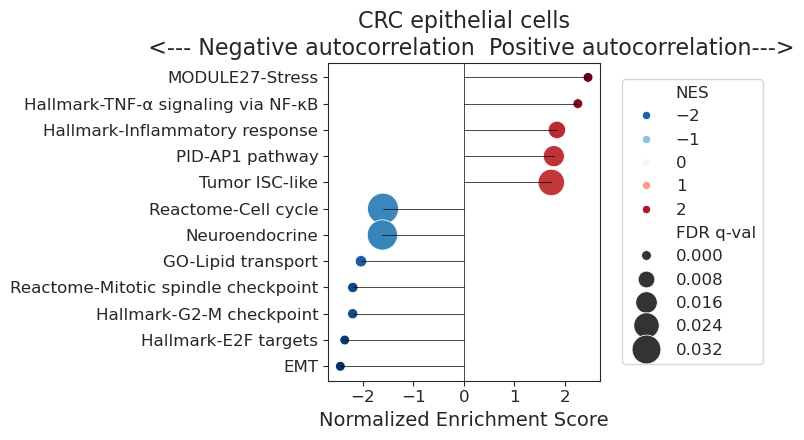

In [17]:
sns.set_style('ticks')

fig_height = 4.5
fig_width = 8

gsea_res_ann_tumor = gsea_res_ann_tumor.sort_values('NES', ascending = False)

plt.figure(figsize=(fig_width, fig_height))
scatter = sns.scatterplot(
    data=gsea_res_ann_tumor, 
    x='NES', 
    y='Term', 
    size='FDR q-val',         
    hue='NES',                
    palette='RdBu_r',         
    sizes=(50, 500),          
    legend='brief'            
)

for _, row in gsea_res_ann_tumor.iterrows():
    plt.plot([0, row['NES']], [row['Term'], row['Term']], color='black', linestyle='-', linewidth=0.5)

plt.title('CRC epithelial cells\n  <--- Negative autocorrelation  Positive autocorrelation--->', fontsize=16)
plt.xlabel('Normalized Enrichment Score', fontsize=14)
plt.ylabel('', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.axvline(x=0, color='black', linewidth=0.5)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    title=None,  
    fontsize=12
)

plt.tight_layout()
plt.savefig(figures_extended_data_1g/'autocorrelation_ZFP_GSEA_tumor.pdf', format='pdf', bbox_inches='tight')

plt.show()

# Normal Cell Types

In [18]:
autocorrelations_normal = pd.read_csv(figures_extended_data_1g / 'hotspot.autocorrelations_normal.tsv', sep='\t', index_col=0)

In [19]:
zfp36l2_correlations_normal = autocorrelations_normal[['ZFP36L2']]
zfp36l2_correlations_normal = zfp36l2_correlations_normal.sort_values(by='ZFP36L2', ascending=False)

In [20]:
zfp36l2_correlations_normal.to_csv(figures_main_1g/"ZFP36L2_autocorrelation_normal.csv")

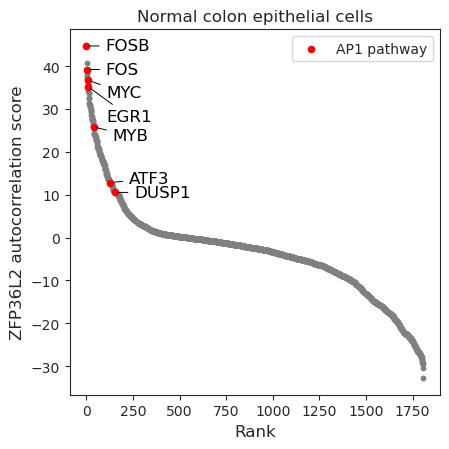

In [21]:
figures_main_1g = figures_main_dir / "figure_1g"
figures_main_1g.mkdir(parents=True, exist_ok=True)

highlight_genes_normal = ['FOSB', 'EGR1', 'FOS','MYC','MYB','JUND','ATF3','DUSP1']
highlight_color_normal = 'red'
label_color_normal = 'black'

plt.figure(figsize=(4.6, 4.6))

zfp36l2_sorted_normal = zfp36l2_correlations_normal.sort_values(by='ZFP36L2', ascending=False)
x = range(len(zfp36l2_sorted_normal))
y = zfp36l2_sorted_normal['ZFP36L2'].values
plt.scatter(x, y, color='gray', s=10)

label_spacing = {
    'PABPC1': -2,
    'EEF2': -3.5,
    'FOS': 0,
    'MYC': -3,
    'EDN1': -4,
    'JUNB': -2,
    'JUN': -3,
    'MYB': -2,
    'EGR1':-7,
    'ATF3':1
}

for i, gene in enumerate(zfp36l2_sorted_normal.index):
    if gene in highlight_genes_normal:
        score = zfp36l2_sorted_normal.loc[gene, 'ZFP36L2']
        plt.scatter(i, score, color=highlight_color_normal, s=20)

        label_x = i + 100
        label_y = score + label_spacing.get(gene, 0)

        plt.annotate(
            gene,
            xy=(i, score),
            xytext=(label_x, label_y),
            textcoords='data',
            fontsize=12,
            color=label_color_normal,
            ha='left',
            va='center',
            arrowprops=dict(arrowstyle='-', color='black', lw=0.7),
        )

plt.xlabel('Rank', fontsize = 12)
plt.ylabel('ZFP36L2 autocorrelation score', fontsize = 12)
plt.title('Normal colon epithelial cells')
plt.scatter([], [], color=highlight_color_normal, label='AP1 pathway', s=20)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig(figures_main_1g/"ZFP36L2_autocorrelation_ranked_genes_normal.pdf", bbox_inches='tight')

plt.show()

### GSEA of Normal Cells Autocorrelation

In [22]:
ranked_genes_normal = zfp36l2_correlations_normal.reset_index()
ranked_genes_normal.columns = ['Gene', 'Correlation']
ranked_genes_normal['Rank'] = ranked_genes_normal['Correlation']

In [23]:
ranked_genes_normal.columns = ['Gene', 'Correlation', 'Rank']

ranked_genes_normal = ranked_genes_normal[['Gene', 'Rank']]

ranked_genes_normal.loc[:, 'Rank'] = pd.to_numeric(ranked_genes_normal['Rank'], errors='coerce')

In [24]:
enr_normal = gp.prerank(
    rnk=ranked_genes_normal,
    gene_sets=str(gmt_file),
    outdir='gsea_results',         
    permutation_num=1000,          
    min_size=15,                   
    max_size=500,                  
    seed=123                       
)

In [25]:
gsea_res_normal = enr_normal.res2d

In [26]:
gsea_res_sig_normal = gsea_res_normal[gsea_res_normal['FDR q-val'] < 0.05]

gsea_res_sig_normal.to_csv(figures_extended_data_1g/'ZFP36L2_autocorrelation_GSEA_results_significant_normal.csv', index=False)

In [27]:
plot_terms_normal = {
    # Positive autocorrelation
    "HALLMARK_MYC_TARGETS_V1": "Hallmark-MYC targets", 
    "HALLMARK_E2F_TARGETS": "Hallmark-E2F targets", 
    "PID_AP1_PATHWAY": "PID-AP1 pathway", 
    "PID_MYC_ACTIV_PATHWAY": "PID-MYC pathway", 
    "HotSpotModule_27.STRESS_": "MODULE27-Stress", 
    "HALLMARK_TNFA_SIGNALING_VIA_NFKB": "Hallmark-TNF-α signaling via NF-κB",
    "HotSpotModule_29.EPI_STEM_CELLS": "Tumor ISC-like", 

    # Negative autocorrelation
    "HotSpotModule_26.INTERFERON": "MODULE26-Interferon",
    "HALLMARK_INTERFERON_ALPHA_RESPONSE": "Hallmark-Interferon α response",
    "HALLMARK_INTERFERON_GAMMA_RESPONSE": "Hallmark-Interferon γ response",
}

gsea_res_ann_normal = (
    gsea_res_sig_normal.copy()
    .assign(Term=lambda df: df["Term"].map(plot_terms_normal))
    .dropna(subset=["Term"])
)

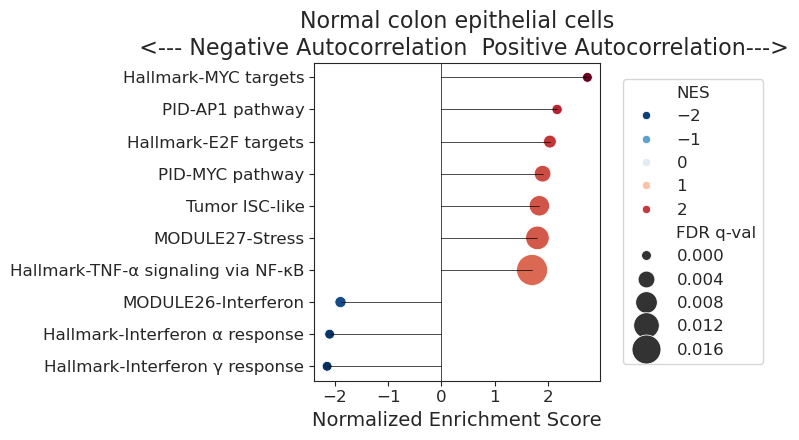

In [28]:
sns.set_style('ticks')

fig_height = 4.5
fig_width = 8

gsea_res_ann_normal = gsea_res_ann_normal.sort_values('NES', ascending = False)

plt.figure(figsize=(fig_width, fig_height))
scatter = sns.scatterplot(
    data=gsea_res_ann_normal, 
    x='NES', 
    y='Term', 
    size='FDR q-val',         
    hue='NES',                
    palette='RdBu_r',         
    sizes=(50, 500),          
    legend='brief'            
)

for _, row in gsea_res_ann_normal.iterrows():
    plt.plot([0, row['NES']], [row['Term'], row['Term']], color='black', linestyle='-', linewidth=0.5)

plt.title('Normal colon epithelial cells\n  <--- Negative Autocorrelation  Positive Autocorrelation--->', fontsize=16)
plt.xlabel('Normalized Enrichment Score', fontsize=14)
plt.ylabel('', fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.axvline(x=0, color='black', linewidth=0.5)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    title=None,  
    fontsize=12
)

plt.tight_layout()
plt.savefig(figures_extended_data_1g/'autocorrelation_ZFP_GSEA_normal.pdf', format='pdf', bbox_inches='tight')

plt.show()

# Autocorrelation GSEA Pathways Shared Across Normal and Tumor Cell Types

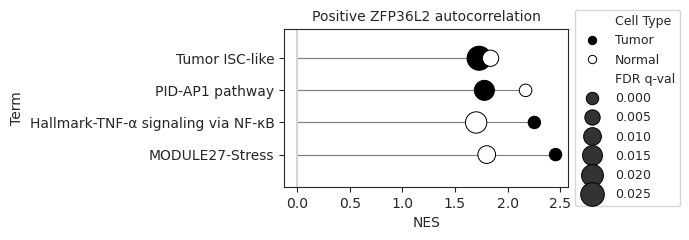

In [29]:
gsea_res_ann_tumor["Cell Type"] = "Tumor"
gsea_res_ann_normal["Cell Type"] = "Normal"

gsea_combined = pd.concat([gsea_res_ann_tumor, gsea_res_ann_normal])

shared_terms = set(gsea_res_ann_tumor['Term']).intersection(gsea_res_ann_normal['Term'])
gsea_filtered = gsea_combined[gsea_combined['Term'].isin(shared_terms)].copy()

gsea_filtered['FDR q-val'] = pd.to_numeric(gsea_filtered['FDR q-val'], errors='coerce')

gsea_filtered = gsea_filtered[
    ~gsea_filtered['Term'].str.contains('BREAST|BRCA', case=False, na=False)
]

pivot_df = gsea_filtered.pivot(index='Term', columns='Cell Type', values='NES').reset_index()

pivot_df = pivot_df[
    ((pivot_df['Tumor'] > 0) & (pivot_df['Normal'] > 0)) |
    ((pivot_df['Tumor'] < 0) & (pivot_df['Normal'] < 0))
]

def categorize_rank(row):
    if row['Tumor'] > 0 and row['Normal'] > 0:
        return ('Both Positive', -(row['Tumor'] + row['Normal']))
    elif row['Tumor'] < 0 and row['Normal'] < 0:
        return ('Both Negative', row['Tumor'] + row['Normal'])  # closer to 0 is higher
    else:
        return ('Other', 0)

pivot_df[['Category', 'RankScore']] = pivot_df.apply(lambda row: pd.Series(categorize_rank(row)), axis=1)

category_order = ['Both Positive', 'Both Negative', 'Other']
pivot_df['Category'] = pd.Categorical(pivot_df['Category'], categories=category_order, ordered=True)
pivot_df = pivot_df.sort_values(by=['Category', 'RankScore'])

pivot_df['Rank'] = range(1, len(pivot_df) + 1)

gsea_filtered = gsea_filtered.merge(pivot_df[['Term', 'Category', 'Rank']], on='Term', how='inner')

gsea_filtered = gsea_filtered.sort_values(by='Rank', ascending=False).reset_index(drop=True)

gsea_filtered['Term'] = pd.Categorical(
    gsea_filtered['Term'],
    categories=pivot_df['Term'],
    ordered=True
)

plt.figure(figsize=(7, 2.5))

for i, row in gsea_filtered.iterrows():
    plt.plot(
        [0, row['NES']],
        [row['Term'], row['Term']],
        color='gray',
        lw=0.8,
        zorder=0
    )

sns.scatterplot(
    data=gsea_filtered,
    x='NES',
    y='Term',
    hue='Cell Type',
    size='FDR q-val',
    sizes=(80, 300),
    palette={'Tumor': 'black', 'Normal': 'white'},
    edgecolor='black',
    legend='brief'
)

plt.axvline(0, color='lightgray', linestyle='-')
plt.title('Positive ZFP36L2 autocorrelation', fontsize=10)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=9,
    frameon=True
)
plt.ylim(gsea_filtered['Term'].nunique(), -0.9) 


plt.savefig(
    figures_main_1i/"ZFP36L2_autocorrelation_gsea_shared_pathways_normal_tumor.pdf",
    format='pdf',
    bbox_inches='tight'
)

plt.tight_layout()
plt.show()